### Category 5: Linear Discriminant Analysis
Computation

In [ ]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

# Define column names
cls = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class']

# Read the data set
dataset = pd.read_csv(url, names=cls)

In [ ]:
# Divide the data set into features (X) and target variable (y)
X = dataset.iloc[:, 0:4].values
y = dataset.iloc[:, 4].values

# Encode the target variable
le = LabelEncoder()
y = le.fit_transform(y)

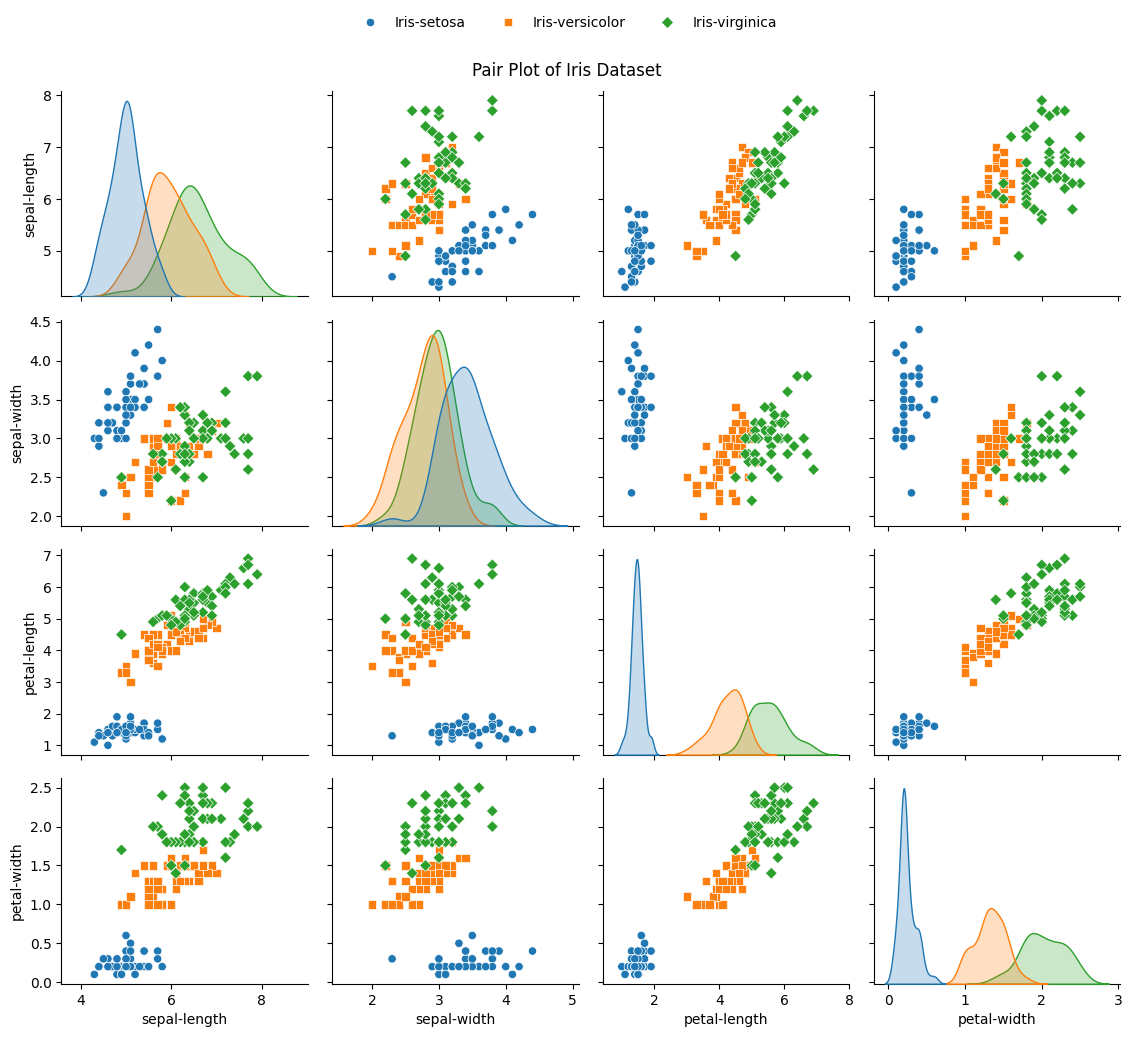

In [ ]:
# Create a pair plot to visualize relationships between different features and species.
ax = sns.pairplot(dataset, hue='Class', markers=["o", "s", "D"])
plt.suptitle("Pair Plot of Iris Dataset")
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False)
plt.tight_layout()
plt.show()

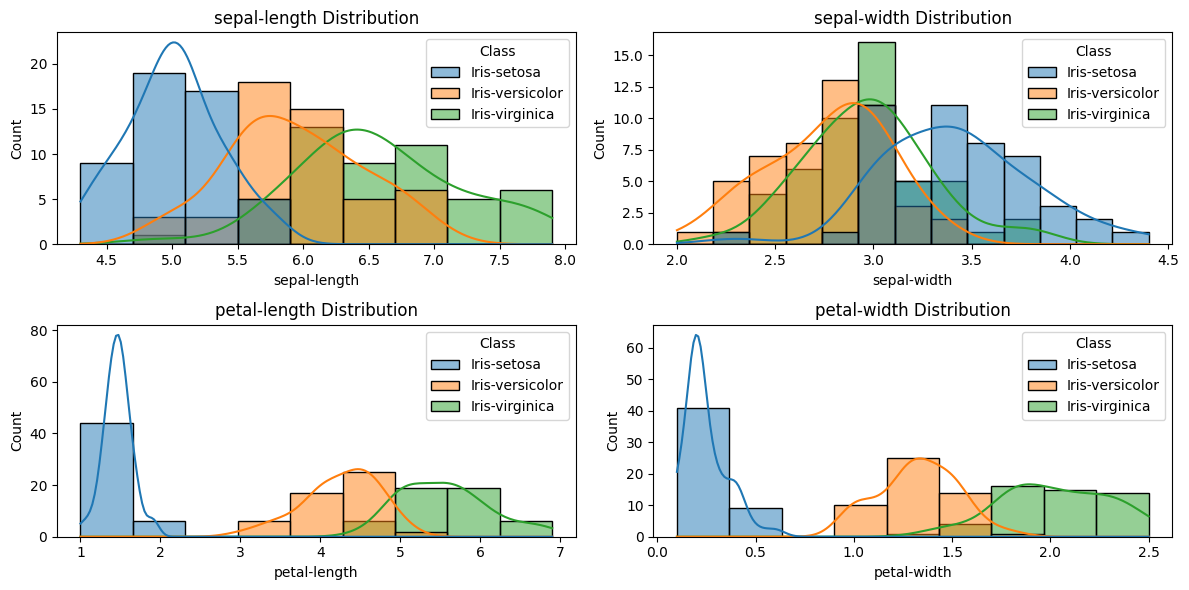

In [ ]:
# Visualize the distribution of each feature using histograms.
plt.figure(figsize=(12, 6))
for i, feature in enumerate(cls[:-1]):
    plt.subplot(2, 2, i + 1)
    sns.histplot(data=dataset, x=feature, hue='Class', kde=True)
    plt.title(f'{feature} Distribution')

plt.tight_layout()
plt.show()

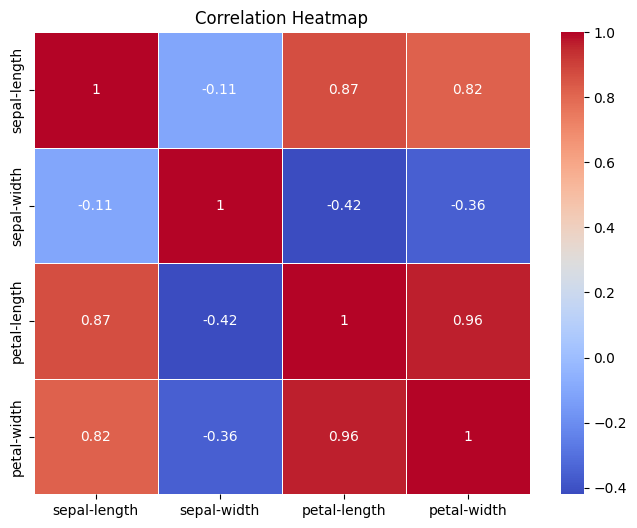

In [ ]:
correlation_matrix = dataset.corr(numeric_only = True)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Split the data set into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
# Apply Linear Discriminant Analysis
lda = LinearDiscriminantAnalysis(n_components=2)
X_train = lda.fit_transform(X_train, y_train)
X_test = lda.transform(X_test)

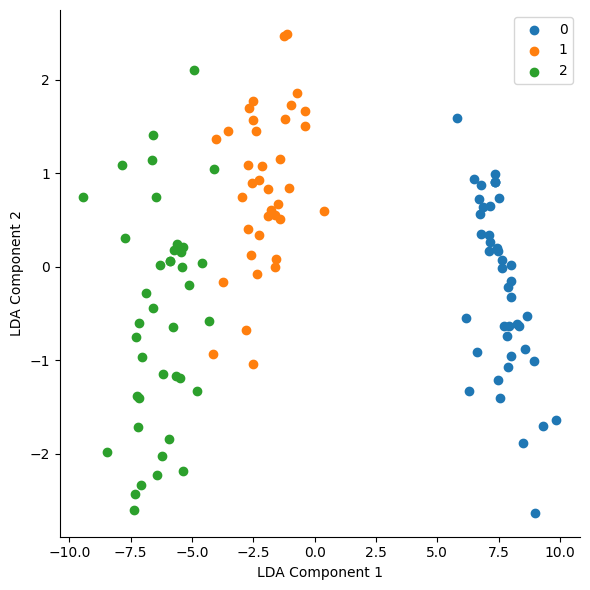

In [ ]:
tmp_Df = pd.DataFrame(X_train, columns=['LDA Component 1','LDA Component 2'])
tmp_Df['Class']=y_train

sns.FacetGrid(tmp_Df, hue ="Class",
              height = 6).map(plt.scatter,
                              'LDA Component 1',
                              'LDA Component 2')

plt.legend(loc='upper right')

In [ ]:
classifier = RandomForestClassifier(max_depth=2, random_state=0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

Accuracy: 0.97


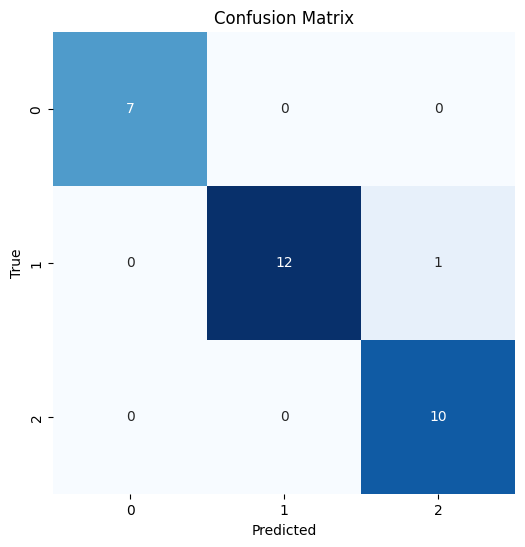

In [ ]:
#Assume 'y_test' and 'y_pred' are already defined
accuracy = accuracy_score(y_test, y_pred)
conf_m = confusion_matrix(y_test, y_pred)

#Display the accuracy
print(f'Accuracy: {accuracy:.2f}')

#Display the confusion matrix as a heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(conf_m, annot=True, fmt="d", cmap="Blues", cbar=False, square=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Illustration

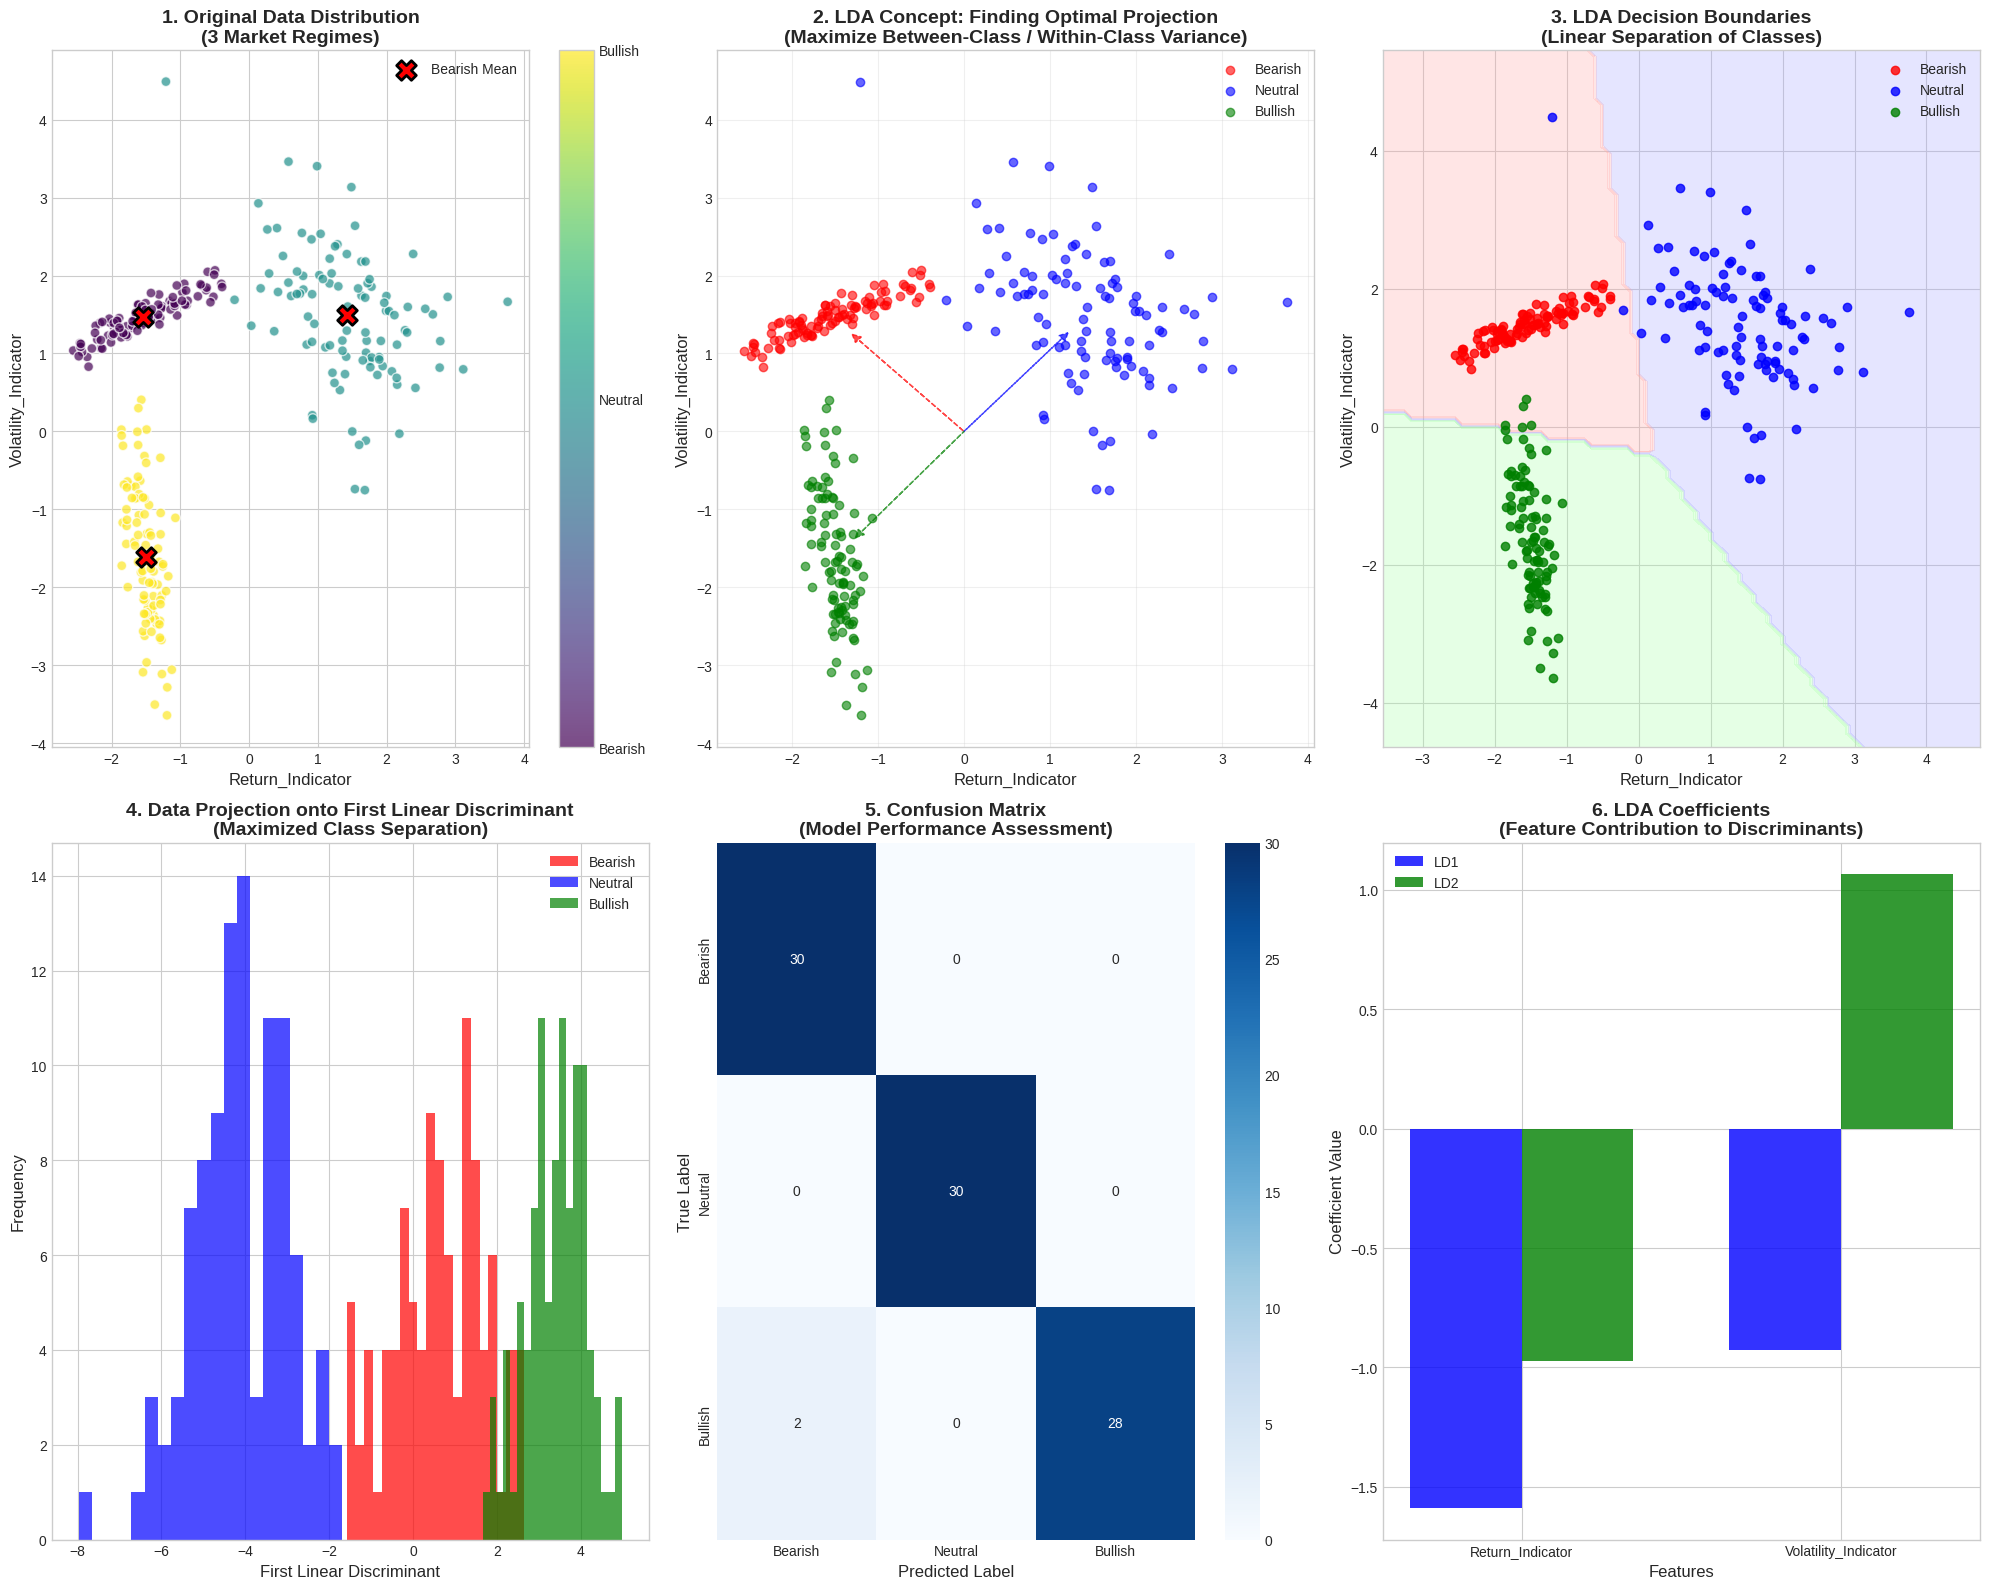

LDA MODEL PERFORMANCE SUMMARY
Training Accuracy: 0.971
Test Accuracy: 0.978

Classification Report:
              precision    recall  f1-score   support

     Bearish       0.94      1.00      0.97        30
     Neutral       1.00      1.00      1.00        30
     Bullish       1.00      0.93      0.97        30

    accuracy                           0.98        90
   macro avg       0.98      0.98      0.98        90
weighted avg       0.98      0.98      0.98        90


LDA MATHEMATICAL COMPONENTS:
Class Priors: [0.33333333 0.33333333 0.33333333]

Class Means:
Bearish: [-1.58769719  1.44318375]
Neutral: [1.42829822 1.56850102]
Bullish: [-1.48800337 -1.65633376]

Discriminant Vectors (Scaling Matrix):
[[-1.58860532 -0.97510317]
 [-0.92801103  1.06608333]]


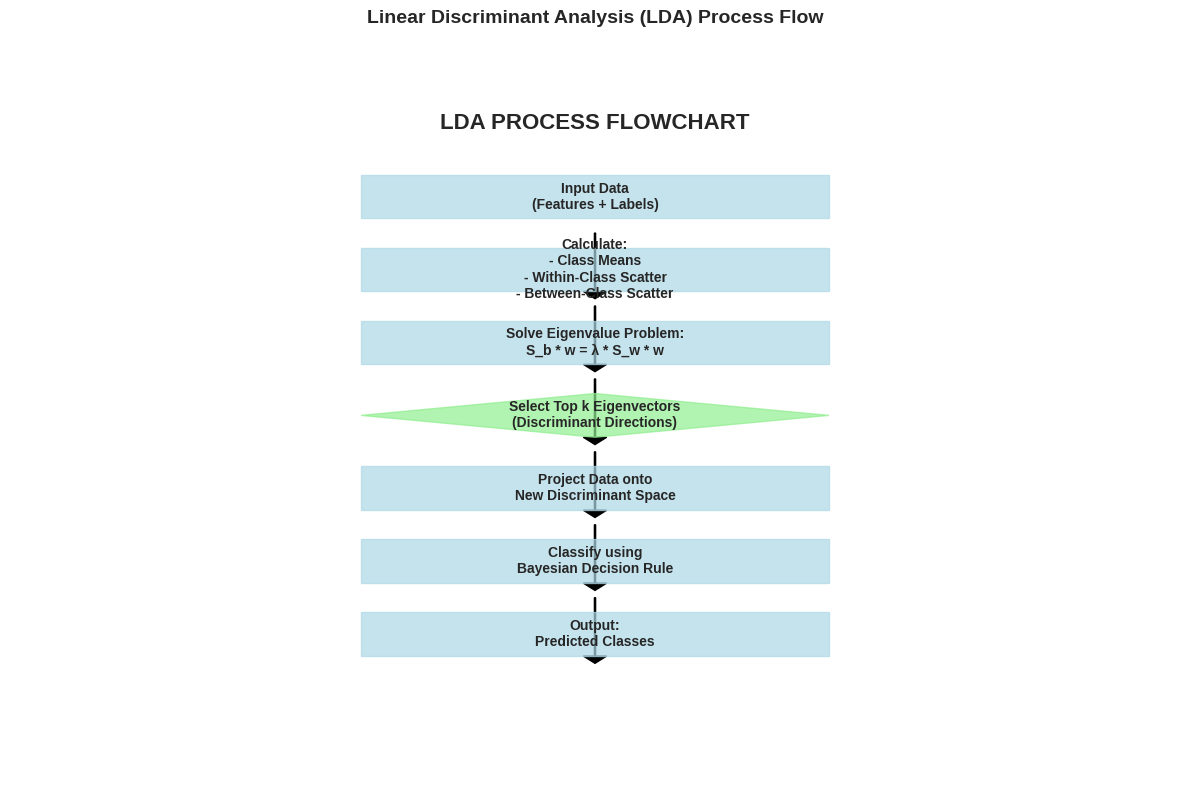

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

# Set style for better visuals
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("tab10")

# Generate sample financial data
np.random.seed(42)
n_samples = 300

# Create synthetic dataset representing financial instrument classification
X, y = make_classification(n_samples=n_samples, n_features=2, n_informative=2,
                          n_redundant=0, n_classes=3, n_clusters_per_class=1,
                          class_sep=1.5, random_state=42)

feature_names = ['Return_Indicator', 'Volatility_Indicator']
class_names = ['Bearish', 'Neutral', 'Bullish']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42, stratify=y)

# Fit LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 16))

# 1. Original Data Distribution
ax1 = plt.subplot(2, 3, 1)
scatter = ax1.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7,
                     edgecolors='w', s=50)
ax1.set_xlabel(feature_names[0], fontsize=12)
ax1.set_ylabel(feature_names[1], fontsize=12)
ax1.set_title('1. Original Data Distribution\n(3 Market Regimes)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(class_names)

# Add class means
means = [X[y == i].mean(axis=0) for i in range(3)]
for i, mean in enumerate(means):
    ax1.scatter(mean[0], mean[1], marker='X', s=200, color='red',
               edgecolors='black', linewidth=2, label=f'{class_names[i]} Mean' if i == 0 else "")
if 0 in y:  # Only add legend once
    ax1.legend()

# 2. LDA Projection Concept Illustration
ax2 = plt.subplot(2, 3, 2)
# Plot original data
colors = ['red', 'blue', 'green']
for i in range(3):
    ax2.scatter(X[y == i, 0], X[y == i, 1], alpha=0.6,
               label=class_names[i], color=colors[i])

# Draw LDA direction lines (simplified representation)
for i, mean in enumerate(means):
    # Draw line from origin to mean (representing discriminant direction)
    ax2.arrow(0, 0, mean[0]*0.8, mean[1]*0.8, head_width=0.1,
              head_length=0.1, fc=colors[i], ec=colors[i], linestyle='--', alpha=0.7)

ax2.set_xlabel(feature_names[0], fontsize=12)
ax2.set_ylabel(feature_names[1], fontsize=12)
ax2.set_title('2. LDA Concept: Finding Optimal Projection\n(Maximize Between-Class / Within-Class Variance)',
              fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. LDA Transformation and Decision Boundaries
ax3 = plt.subplot(2, 3, 3)
# Create mesh grid for decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict on mesh grid
Z = lda.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries
from matplotlib.colors import ListedColormap
cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF', '#AAFFAA'])
ax3.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

# Plot original data
for i in range(3):
    ax3.scatter(X[y == i, 0], X[y == i, 1], alpha=0.8,
               label=class_names[i], color=colors[i])

ax3.set_xlabel(feature_names[0], fontsize=12)
ax3.set_ylabel(feature_names[1], fontsize=12)
ax3.set_title('3. LDA Decision Boundaries\n(Linear Separation of Classes)',
              fontsize=14, fontweight='bold')
ax3.legend()

# 4. Projection onto LDA Components
ax4 = plt.subplot(2, 3, 4)
# Transform data using LDA
X_lda = lda.transform(X)

# Plot the first linear discriminant (most important direction)
for i in range(3):
    ax4.hist(X_lda[y == i, 0], bins=20, alpha=0.7,
            label=class_names[i], color=colors[i])

ax4.set_xlabel('First Linear Discriminant', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.set_title('4. Data Projection onto First Linear Discriminant\n(Maximized Class Separation)',
              fontsize=14, fontweight='bold')
ax4.legend()

# 5. Confusion Matrix
ax5 = plt.subplot(2, 3, 5)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=class_names, yticklabels=class_names, ax=ax5)
ax5.set_xlabel('Predicted Label', fontsize=12)
ax5.set_ylabel('True Label', fontsize=12)
ax5.set_title('5. Confusion Matrix\n(Model Performance Assessment)',
              fontsize=14, fontweight='bold')

# 6. LDA Mathematical Components Visualization
ax6 = plt.subplot(2, 3, 6)
# Visualize the discriminant vectors
discriminant_vectors = lda.scalings_

# Create a bar plot showing the feature importance in discriminants
features = feature_names
x_pos = np.arange(len(features))
width = 0.35

ax6.bar(x_pos - width/2, discriminant_vectors[:, 0], width,
       label='LD1', alpha=0.8, color='blue')
ax6.bar(x_pos + width/2, discriminant_vectors[:, 1], width,
       label='LD2', alpha=0.8, color='green')

ax6.set_xlabel('Features', fontsize=12)
ax6.set_ylabel('Coefficient Value', fontsize=12)
ax6.set_title('6. LDA Coefficients\n(Feature Contribution to Discriminants)',
              fontsize=14, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(features)
ax6.legend()

plt.tight_layout()
plt.show()

# Additional statistical information
print("LDA MODEL PERFORMANCE SUMMARY")
print("="*50)
print(f"Training Accuracy: {lda.score(X_train, y_train):.3f}")
print(f"Test Accuracy: {lda.score(X_test, y_test):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

print("\nLDA MATHEMATICAL COMPONENTS:")
print("="*50)
print("Class Priors:", lda.priors_)
print("\nClass Means:")
for i, mean in enumerate(lda.means_):
    print(f"{class_names[i]}: {mean}")

print(f"\nDiscriminant Vectors (Scaling Matrix):")
print(lda.scalings_)

# Create a separate figure for the LDA process flowchart
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Simplified LDA process flowchart
ax.text(0.5, 0.9, 'LDA PROCESS FLOWCHART', ha='center', va='center',
        fontsize=16, fontweight='bold', transform=ax.transAxes)

# Draw flowchart elements
flow_elements = [
    (0.5, 0.8, 'Input Data\n(Features + Labels)', 'rectangle'),
    (0.5, 0.7, 'Calculate:\n- Class Means\n- Within-Class Scatter\n- Between-Class Scatter', 'rectangle'),
    (0.5, 0.6, 'Solve Eigenvalue Problem:\nS_b * w = λ * S_w * w', 'rectangle'),
    (0.5, 0.5, 'Select Top k Eigenvectors\n(Discriminant Directions)', 'diamond'),
    (0.5, 0.4, 'Project Data onto\nNew Discriminant Space', 'rectangle'),
    (0.5, 0.3, 'Classify using\nBayesian Decision Rule', 'rectangle'),
    (0.5, 0.2, 'Output:\nPredicted Classes', 'rectangle')
]

for i, (x, y, text, shape) in enumerate(flow_elements):
    if shape == 'rectangle':
        ax.add_patch(plt.Rectangle((x-0.2, y-0.03), 0.4, 0.06,
                                 fill=True, color='lightblue', alpha=0.7))
    else:  # diamond
        ax.add_patch(plt.Polygon([(x, y+0.03), (x+0.2, y), (x, y-0.03), (x-0.2, y)],
                              fill=True, color='lightgreen', alpha=0.7))

    ax.text(x, y, text, ha='center', va='center', fontsize=10,
           fontweight='bold', transform=ax.transAxes)

    # Draw arrows
    if i < len(flow_elements) - 1:
        ax.arrow(x, y-0.05, 0, -0.08, head_width=0.02, head_length=0.01,
                fc='black', ec='black', transform=ax.transAxes)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Linear Discriminant Analysis (LDA) Process Flow',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Category 7: Neural Network

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving sp500_features.csv to sp500_features (1).csv


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0811 - val_loss: 0.8776
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0243 - val_loss: 0.8672
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9628 - val_loss: 0.8656
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9523 - val_loss: 0.8655
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9459 - val_loss: 0.8692
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9105 - val_loss: 0.8664
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9300 - val_loss: 0.8663
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0134 - val_loss: 0.8678
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8971 - val_loss: 0.8709
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9507 - val_loss: 0.8596
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9896 - val_loss: 0.8525
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9437 - val_l

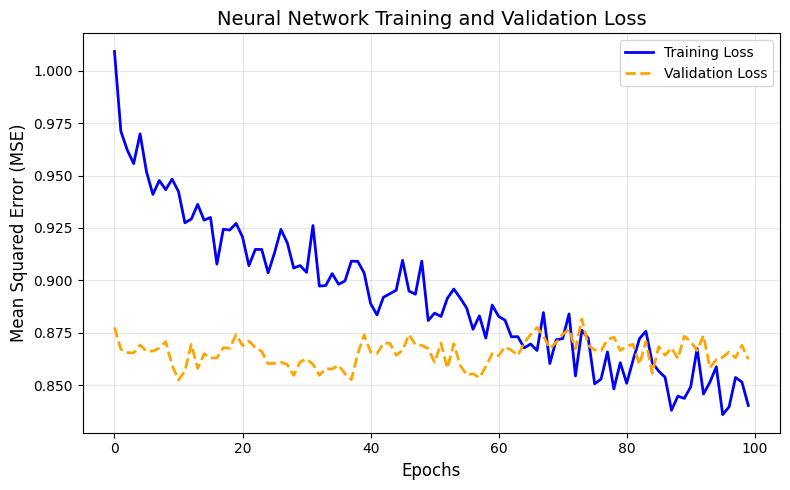

In [ ]:
# 1.Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 2.Load dataset
data = pd.read_csv("sp500_features.csv")

# 3. Prepare features (X) and target (y)
X = data.drop("next_return", axis=1)
y = data["next_return"]

# 4. Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, shuffle=False
)

#6.Build Neural Network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression
])

# 7.Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# 8. Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# 9.Evaluate model performance
mse = model.evaluate(X_test, y_test, verbose=0)
print(f" Test MSE: {mse:.6f}")

#10. Plot training and validation loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--', linewidth=2)
plt.title('Neural Network Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Category 6: Support Vector Machines (SVMs)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC, SVR
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error
from sklearn.datasets import make_classification, make_regression
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("=" * 70)
print("SVM FOR FINANCIAL APPLICATIONS - COMPREHENSIVE IMPLEMENTATION")
print("=" * 70)

SVM FOR FINANCIAL APPLICATIONS - COMPREHENSIVE IMPLEMENTATION


In [ ]:
print("\n1. GENERATING SYNTHETIC FINANCIAL DATA")
print("-" * 40)

# Generate synthetic financial data for classification
np.random.seed(42)
n_samples = 1000

# Features: Returns, Volatility, Volume, Momentum
returns = np.random.normal(0, 1, n_samples)
volatility = np.random.normal(0, 2, n_samples)
volume = np.random.normal(0, 1.5, n_samples)
momentum = np.random.normal(0, 1.2, n_samples)

# Create target: 1 for positive returns next period, 0 for negative
target_classification = ((returns + 0.3*volatility + 0.2*momentum + np.random.normal(0, 0.5, n_samples)) > 0).astype(int)

# Create regression target: future returns
target_regression = returns * 0.7 + volatility * 0.3 + np.random.normal(0, 0.3, n_samples)

# Create DataFrame
classification_data = pd.DataFrame({
    'Returns': returns,
    'Volatility': volatility,
    'Volume': volume,
    'Momentum': momentum,
    'Market_Direction': target_classification
})

regression_data = pd.DataFrame({
    'Returns': returns,
    'Volatility': volatility,
    'Volume': volume,
    'Momentum': momentum,
    'Future_Returns': target_regression
})

print(f"Classification Data Shape: {classification_data.shape}")
print(f"Regression Data Shape: {regression_data.shape}")
print("\nClassification Data Overview:")
print(classification_data.head())


1. GENERATING SYNTHETIC FINANCIAL DATA
----------------------------------------
Classification Data Shape: (1000, 5)
Regression Data Shape: (1000, 5)

Classification Data Overview:
    Returns  Volatility    Volume  Momentum  Market_Direction
0  0.496714    2.798711 -1.012767 -2.289369                 1
1 -0.138264    1.849267 -0.216778 -1.032462                 1
2  0.647689    0.119261 -1.188630 -0.496327                 1
3  1.523030   -1.293874 -0.461942  2.265225                 1
4 -0.234153    1.396447 -2.840422  0.667864                 0


In [ ]:
# =============================================================================
# 2. SVM CLASSIFICATION FOR MARKET DIRECTION PREDICTION
# =============================================================================

print("\n" + "=" * 60)
print("2. SVM CLASSIFICATION IMPLEMENTATION")
print("=" * 60)

# Prepare data for classification
X_class = classification_data[['Returns', 'Volatility', 'Volume', 'Momentum']]
y_class = classification_data['Market_Direction']

# Split the data
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.3, random_state=42, stratify=y_class
)

# Scale the features
scaler_class = StandardScaler()
X_train_class_scaled = scaler_class.fit_transform(X_train_class)
X_test_class_scaled = scaler_class.transform(X_test_class)

# Initialize different SVM classifiers
svm_linear = SVC(kernel='linear', random_state=42)
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_poly = SVC(kernel='poly', degree=3, random_state=42)

classifiers = {
    'Linear SVM': svm_linear,
    'RBF SVM': svm_rbf,
    'Polynomial SVM': svm_poly
}

# Train and evaluate classifiers
results_classification = {}

for name, clf in classifiers.items():
    clf.fit(X_train_class_scaled, y_train_class)
    y_pred = clf.predict(X_test_class_scaled)
    accuracy = accuracy_score(y_test_class, y_pred)
    results_classification[name] = {
        'accuracy': accuracy,
        'predictions': y_pred,
        'model': clf
    }

    print(f"\n{name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test_class, y_pred))

# =============================================================================
# 3. SVM REGRESSION FOR RETURNS PREDICTION
# =============================================================================


2. SVM CLASSIFICATION IMPLEMENTATION

Linear SVM Results:
Accuracy: 0.8567
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86       149
           1       0.86      0.86      0.86       151

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300


RBF SVM Results:
Accuracy: 0.8500
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       149
           1       0.86      0.83      0.85       151

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300


Polynomial SVM Results:
Accuracy: 0.8400
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       149
           1   

In [ ]:
print("\n" + "=" * 60)
print("3. SVM REGRESSION IMPLEMENTATION")
print("=" * 60)

# Prepare data for regression
X_reg = regression_data[['Returns', 'Volatility', 'Volume', 'Momentum']]
y_reg = regression_data['Future_Returns']

# Split the data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

# Scale the features
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# Initialize SVM regressors
svr_linear = SVR(kernel='linear')
svr_rbf = SVR(kernel='rbf')

regressors = {
    'Linear SVR': svr_linear,
    'RBF SVR': svr_rbf
}

# Train and evaluate regressors
results_regression = {}

for name, reg in regressors.items():
    reg.fit(X_train_reg_scaled, y_train_reg)
    y_pred = reg.predict(X_test_reg_scaled)
    mse = mean_squared_error(y_test_reg, y_pred)
    rmse = np.sqrt(mse)

    results_regression[name] = {
        'mse': mse,
        'rmse': rmse,
        'predictions': y_pred
    }

    print(f"\n{name} Results:")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")

# =============================================================================
# 4. HYPERPARAMETER TUNING WITH GRID SEARCH
# =============================================================================


3. SVM REGRESSION IMPLEMENTATION

Linear SVR Results:
MSE: 0.0923
RMSE: 0.3038

RBF SVR Results:
MSE: 0.1365
RMSE: 0.3695


In [ ]:
# =============================================================================
# 4. HYPERPARAMETER TUNING WITH GRID SEARCH
# =============================================================================

print("\n" + "=" * 70)
print("4. HYPERPARAMETER TUNING WITH GRID SEARCH")
print("=" * 70)

print("Performing Grid Search for SVM Classification...")

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

# Perform grid search
grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_class_scaled, y_train_class)

print("\nGrid Search Results:")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-validation Score: {grid_search.best_score_:.4f}")

# Evaluate best model
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test_class_scaled)
best_accuracy = accuracy_score(y_test_class, y_pred_best)
print(f"Test Accuracy with Best Model: {best_accuracy:.4f}")

# =============================================================================
# 5. REAL FINANCIAL DATA APPLICATION - S&P 500 PREDICTION
# =============================================================================

print("\n" + "=" * 70)
print("5. REAL FINANCIAL DATA APPLICATION")
print("=" * 70)

def prepare_financial_data(symbol='^GSPC', period='2y'):
    """Download and prepare financial data for SVM prediction"""
    print(f"Downloading {symbol} data...")
    stock_data = yf.download(symbol, period=period, progress=False)

    # Calculate technical indicators
    stock_data['Returns'] = stock_data['Close'].pct_change()
    stock_data['Volatility'] = stock_data['Returns'].rolling(window=20).std()
    stock_data['Volume_SMA'] = stock_data['Volume'].rolling(window=20).mean()
    stock_data['Momentum'] = stock_data['Close'] / stock_data['Close'].shift(5) - 1

    # Create target: 1 if next day return positive, 0 otherwise
    stock_data['Target'] = (stock_data['Returns'].shift(-1) > 0).astype(int)

    # Drop NaN values
    stock_data = stock_data.dropna()

    return stock_data

# Get S&P 500 data
sp500_data = prepare_financial_data()

print(f"Financial Data Shape: {sp500_data.shape}")
print(f"Columns: {sp500_data.columns.tolist()}")

# Prepare features and target
feature_columns = ['Returns', 'Volatility', 'Volume_SMA', 'Momentum']
X_finance = sp500_data[feature_columns]
y_finance = sp500_data['Target']

# Split data (time series split would be better, but using simple split for demonstration)
X_train_fin, X_test_fin, y_train_fin, y_test_fin = train_test_split(
    X_finance, y_finance, test_size=0.3, random_state=42, shuffle=False
)

# Scale features
scaler_fin = StandardScaler()
X_train_fin_scaled = scaler_fin.fit_transform(X_train_fin)
X_test_fin_scaled = scaler_fin.transform(X_test_fin)

# Train SVM on financial data
svm_finance = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_finance.fit(X_train_fin_scaled, y_train_fin)

# Predict and evaluate
y_pred_finance = svm_finance.predict(X_test_fin_scaled)
finance_accuracy = accuracy_score(y_test_fin, y_pred_finance)

print(f"\nSVM Accuracy on S&P 500 Direction Prediction: {finance_accuracy:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_fin, y_pred_finance))

# =============================================================================
# 6. VISUALIZATIONS
# =============================================================================


4. HYPERPARAMETER TUNING WITH GRID SEARCH
Performing Grid Search for SVM Classification...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Grid Search Results:
Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-validation Score: 0.8657
Test Accuracy with Best Model: 0.8533

5. REAL FINANCIAL DATA APPLICATION
Financial Data Shape: (481, 10)
Columns: [('Close', '^GSPC'), ('High', '^GSPC'), ('Low', '^GSPC'), ('Open', '^GSPC'), ('Volume', '^GSPC'), ('Returns', ''), ('Volatility', ''), ('Volume_SMA', ''), ('Momentum', ''), ('Target', '')]

SVM Accuracy on S&P 500 Direction Prediction: 0.5517
Confusion Matrix:
[[31 29]
 [36 49]]



6. GENERATING VISUALIZATIONS


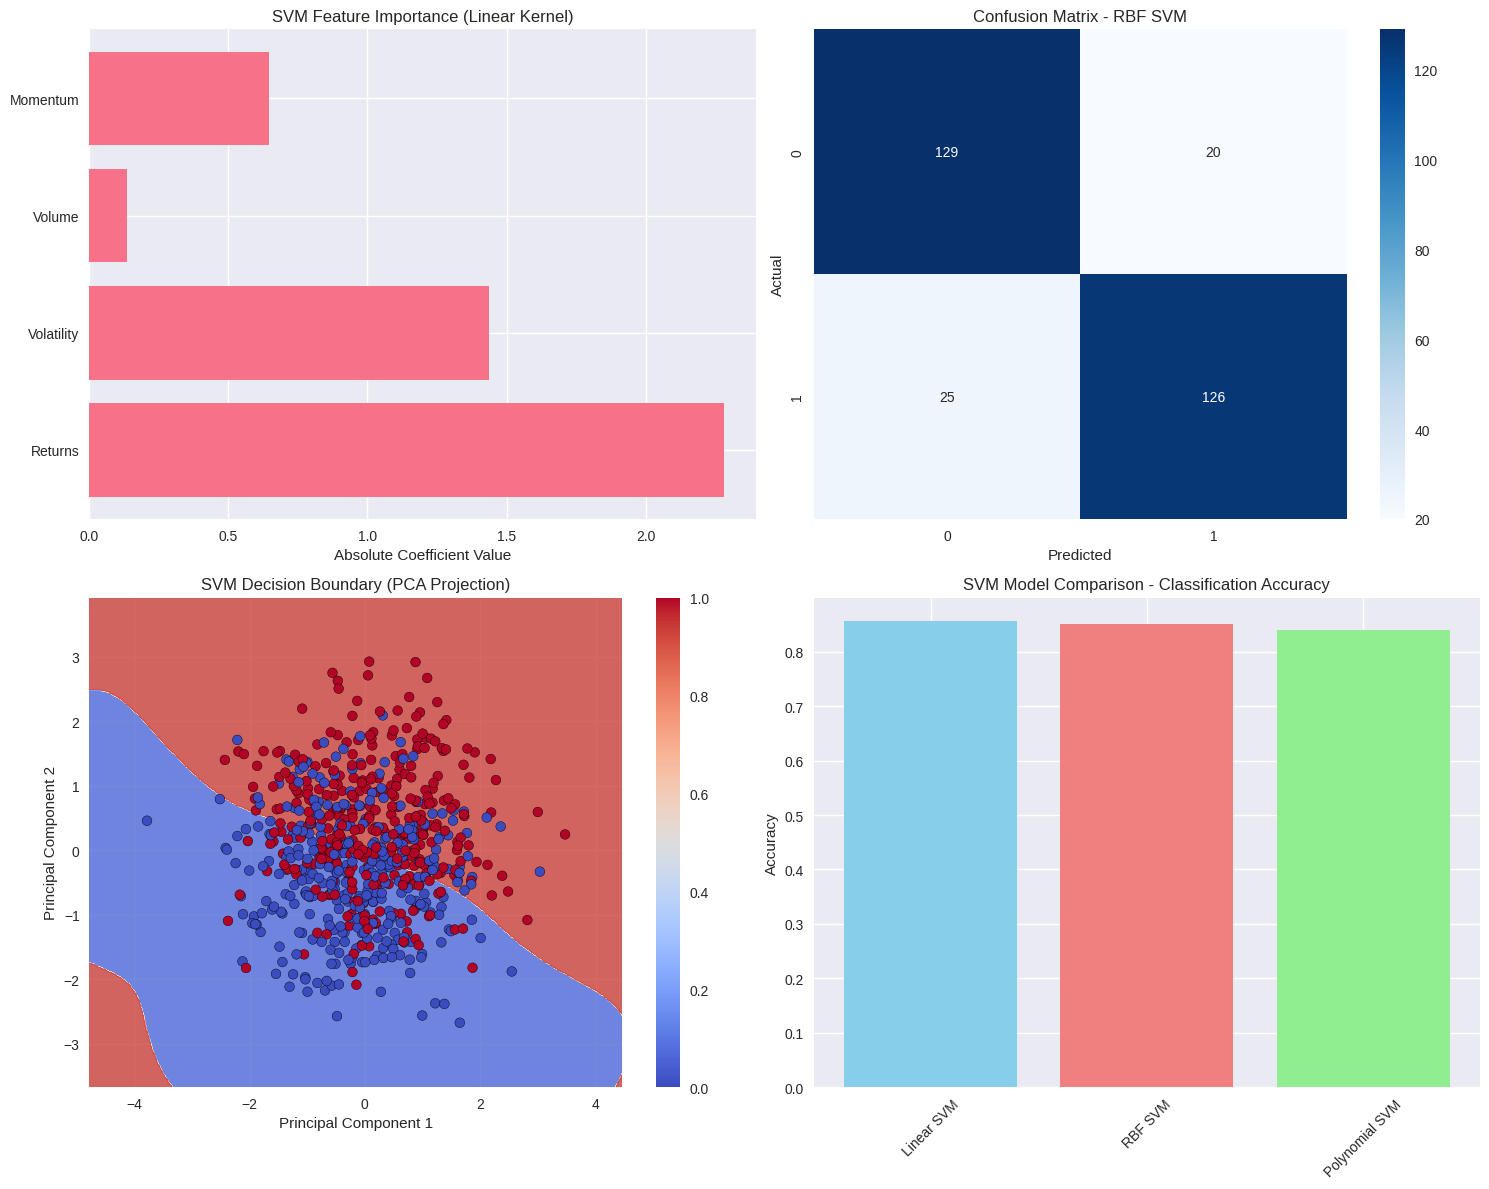

In [ ]:
# =============================================================================
# 6. VISUALIZATIONS
# =============================================================================

print("\n" + "=" * 50)
print("6. GENERATING VISUALIZATIONS")
print("=" * 50)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Feature importance from linear SVM
linear_svm = SVC(kernel='linear', random_state=42)
linear_svm.fit(X_train_class_scaled, y_train_class)
feature_importance = np.abs(linear_svm.coef_[0])
features = ['Returns', 'Volatility', 'Volume', 'Momentum']

axes[0, 0].barh(features, feature_importance)
axes[0, 0].set_title('SVM Feature Importance (Linear Kernel)')
axes[0, 0].set_xlabel('Absolute Coefficient Value')

# 2. Confusion Matrix
cm = confusion_matrix(y_test_class, results_classification['RBF SVM']['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('Confusion Matrix - RBF SVM')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# 3. SVM Decision Boundary (2D projection)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_class_scaled)

# Train SVM on PCA components
svm_2d = SVC(kernel='rbf', random_state=42)
svm_2d.fit(X_pca, y_train_class)

# Create mesh for decision boundary
h = 0.02
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

axes[1, 0].contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
scatter = axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_train_class, cmap=plt.cm.coolwarm, edgecolors='k')
axes[1, 0].set_title('SVM Decision Boundary (PCA Projection)')
axes[1, 0].set_xlabel('Principal Component 1')
axes[1, 0].set_ylabel('Principal Component 2')
plt.colorbar(scatter, ax=axes[1, 0])

# 4. Model Comparison
models = list(results_classification.keys())
accuracies = [results_classification[model]['accuracy'] for model in models]

axes[1, 1].bar(models, accuracies, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1, 1].set_title('SVM Model Comparison - Classification Accuracy')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('svm_financial_analysis.png', dpi=300, bbox_inches='tight')
plt.show()